# Version 2 Retention Model Comparison

Checkpoint 41 compares fixed candidates on the 2024 temporal validation period. The 2025 test target remains reserved.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'

comparison = pd.read_csv(PROCESSED_DIR / 'model_comparison_v2.csv')
grouped = pd.read_csv(PROCESSED_DIR / 'model_grouped_cv_metrics.csv')
pairwise = pd.read_csv(PROCESSED_DIR / 'model_pairwise_pr_auc_bootstrap.csv')
selection = pd.read_csv(PROCESSED_DIR / 'model_selection_decision_v2.csv')
predictions = pd.read_csv(PROCESSED_DIR / 'retention_validation_predictions_v2.csv')
checks = pd.read_csv(PROCESSED_DIR / 'model_comparison_validation.csv')

print(f'Candidate models: {len(comparison)}')
print(f'Validation employees per model: {predictions.employee_id.nunique():,}')
print(f'Integrity checks passed: {checks.status.eq("PASS").sum()}/{len(checks)}')

Candidate models: 3
Validation employees per model: 5,521
Integrity checks passed: 13/13


## Primary temporal validation

Models are fitted on 2023 and evaluated on 2024. PR-AUC is the primary ranking metric because attrition is uncommon.

In [2]:
comparison[[
    'model', 'pr_auc', 'pr_auc_lower_95', 'pr_auc_upper_95',
    'roc_auc', 'brier_score', 'top_decile_lift',
    'top_decile_capture', 'selected_model'
]].sort_values('pr_auc', ascending=False)

,model,pr_auc,pr_auc_lower_95,pr_auc_upper_95,roc_auc,brier_score,top_decile_lift,top_decile_capture,selected_model
0,Logistic Regression,0.163814,0.148181,0.185694,0.621134,0.240336,1.857041,0.186007,True
1,Gradient Boosting,0.161487,0.148266,0.179913,0.629324,0.207268,1.754819,0.175768,False
2,Random Forest,0.152314,0.140927,0.168136,0.623300,0.172176,1.737782,0.174061,False


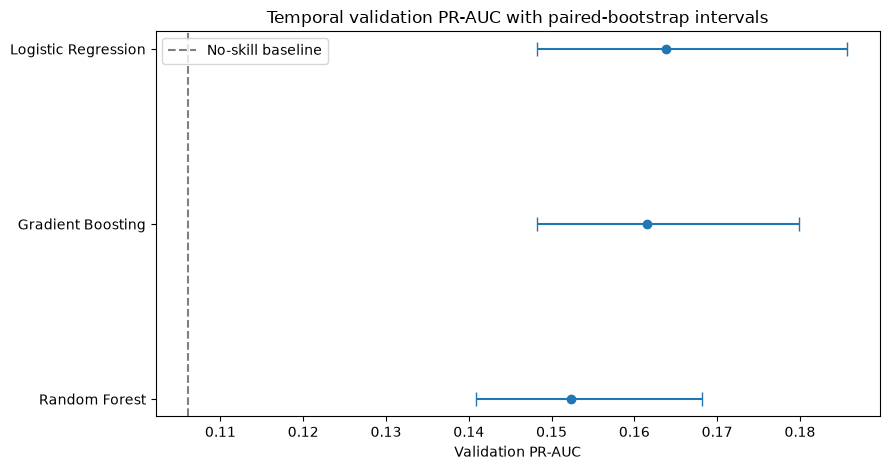

In [3]:
plot_data = comparison.sort_values('pr_auc')
lower_error = plot_data['pr_auc'] - plot_data['pr_auc_lower_95']
upper_error = plot_data['pr_auc_upper_95'] - plot_data['pr_auc']

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.errorbar(
    plot_data['pr_auc'], plot_data['model'],
    xerr=[lower_error, upper_error], fmt='o', capsize=5
)
ax.axvline(plot_data['positive_rate'].iloc[0], color='gray', linestyle='--', label='No-skill baseline')
ax.set_xlabel('Validation PR-AUC')
ax.set_title('Temporal validation PR-AUC with paired-bootstrap intervals')
ax.legend()
plt.tight_layout()
plt.show()

## Employee-grouped robustness

Each employee belongs to exactly one fold, so training and validation employees do not overlap within a fold.

In [4]:
grouped.pivot(index='fold', columns='model', values='pr_auc')

model,Gradient Boosting,Logistic Regression,Random Forest
fold,,,
1,0.173071,0.167227,0.151876
2,0.180305,0.181437,0.160892
3,0.140255,0.146465,0.141370
4,0.166221,0.162414,0.167155
5,0.172080,0.175062,0.155766


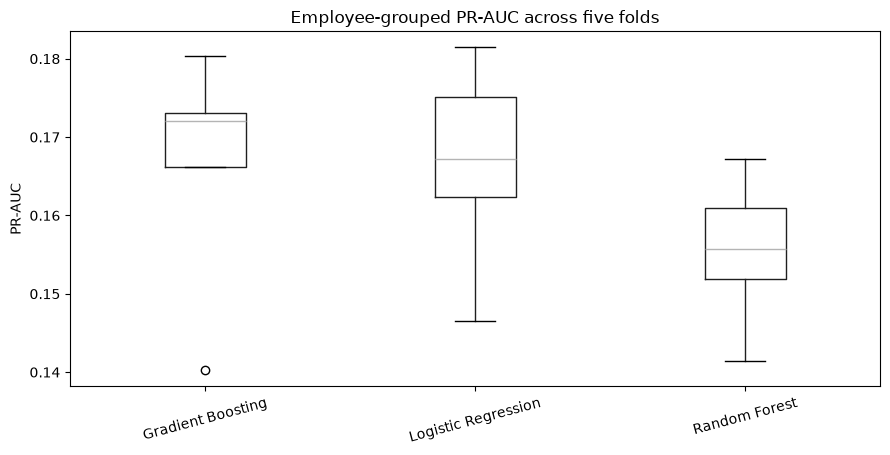

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.8))
grouped.boxplot(column='pr_auc', by='model', ax=ax, grid=False)
ax.set_title('Employee-grouped PR-AUC across five folds')
ax.set_xlabel('')
ax.set_ylabel('PR-AUC')
plt.suptitle('')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Paired uncertainty and provisional selection

An interval containing zero means the observed PR-AUC difference is inconclusive. Simplicity is used only after performance and uncertainty are considered.

In [6]:
pairwise

,model_a,model_b,observed_pr_auc_difference_a_minus_b,bootstrap_mean_difference,difference_lower_95,difference_upper_95,interval_includes_zero,conclusion
0,Logistic Regression,Gradient Boosting,0.002328,0.001787,-0.011130,0.015905,True,Inconclusive
1,Logistic Regression,Random Forest,0.011500,0.011457,-0.002831,0.028611,True,Inconclusive
2,Gradient Boosting,Random Forest,0.009172,0.009669,0.000309,0.020455,False,Gradient Boosting higher


In [7]:
selection[[
    'model', 'validation_pr_auc', 'gap_from_best_pr_auc',
    'paired_interval_includes_zero', 'within_practical_tolerance',
    'complexity_rank', 'selected_model'
]]

,model,validation_pr_auc,gap_from_best_pr_auc,paired_interval_includes_zero,within_practical_tolerance,complexity_rank,selected_model
0,Logistic Regression,0.163814,0.000000,True,True,1,True
1,Gradient Boosting,0.161487,0.002328,True,True,2,False
2,Random Forest,0.152314,0.011500,True,False,3,False


## Validation checks

The test population is counted from target-free assignments only. No test targets or probabilities are produced in this checkpoint.

In [8]:
checks

,check,status,observed,requirement,details
0,Reserved test target remains unused,PASS,6641 reserved rows; 0 test targets used,Reserved rows > 0 and target usage = 0,Only train and validation assignments were joi...
1,Primary train and validation rows are separate,PASS,0,0 overlapping employee-snapshot keys,"The same employee may recur later, but one row..."
2,Validation population is sufficiently large,PASS,5521,>= 1000,Primary model comparison requires a useful fut...
3,Validation has sufficient positive cases,PASS,586,>= 100,PR-AUC and ranking metrics require attrition e...
4,Every configured candidate was evaluated,PASS,"['Gradient Boosting', 'Logistic Regression', '...","['Gradient Boosting', 'Logistic Regression', '...",No model may be silently skipped.
5,Validation probabilities are finite and bounded,PASS,"[True, True, True]",All True,Every candidate must output valid probabilities.
6,Primary probability and classification metrics...,PASS,True,True,Metrics expressed as rates must remain between...
7,All grouped model-fold evaluations completed,PASS,15,15,Every candidate must run in every employee-gro...
8,Grouped robustness folds are employee-disjoint,PASS,0,0 overlapping employees,No fold may train and validate on one employee.
9,Paired validation bootstraps completed,PASS,1500,1500,Every iteration uses one shared resample acros...
